
# 🤖 TOOTY - Análise de evidências digitais
>   - Construção de modelo de IA para identificação de entidades em evidências digitais.
>  - Usuário deve informar um diretório com os dados...
>> - **Imagens: Identificação de objetos; (Implementado)**
> - Implementado dois novos treinamentos:
>> - Paciencia de 5 epocas - interrompe de forma automatica quando há perda na Validação ((val_loss);
>> - Após a 50ª epoca, executa analise do val_loss com paciencia de 5 epocas. Ao final emite 5 matrizes de confusão (Primeira Epoca; 25%; 50%; 75%; Última Epoca)




### **1 - Importação das bibliotecas e tratamento das classes**

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from collections import Counter

In [ ]:
# Carregar o CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Treino:", x_train.shape)
print("Teste :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1676s 10us/step
Treino: (50000, 32, 32, 3)
Teste : (10000, 32, 32, 3)


In [ ]:
# Classes das imagens
class_names = ['aviao', 'automovel', 'passaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'barco', 'caminhao']

### **2 - Vizualização dos dados**

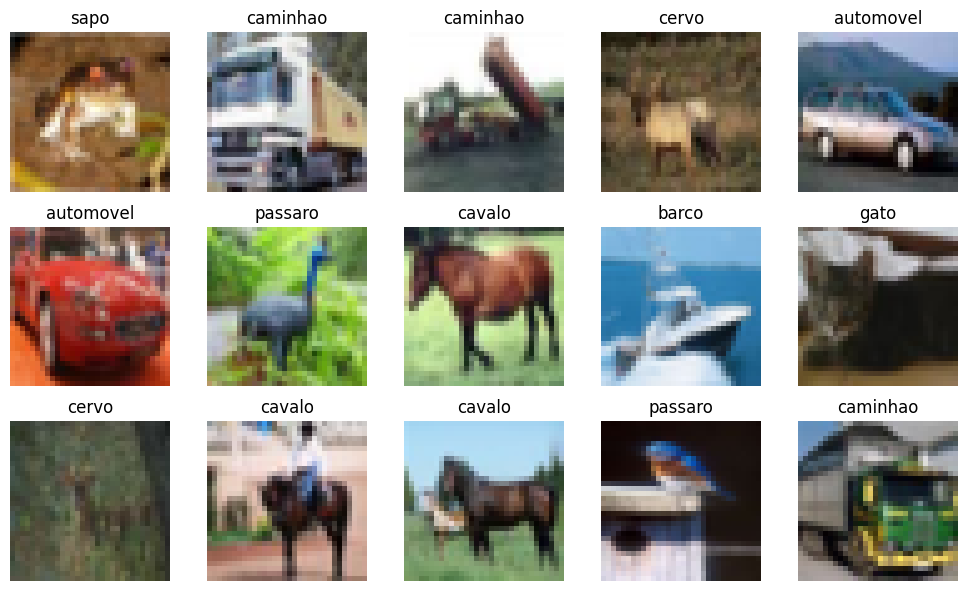

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### **3. Pré-processamento**

In [ ]:
print("Antes:", x_train.min(), "a", x_train.max())

# Normalização: 0–255 → 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Depois:", x_train.min(), "a", x_train.max())

Antes: 0 a 255
Depois: 0.0 a 1.0


### **4. Construção do Modelo**

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### **5. Treinamento + Validação**

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 50ms/step - accuracy: 0.4583 - loss: 1.5021 - val_accuracy: 0.5595 - val_loss: 1.2436
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - accuracy: 0.5963 - loss: 1.1486 - val_accuracy: 0.6245 - val_loss: 1.0782
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.6492 - loss: 1.0083 - val_accuracy: 0.6458 - val_loss: 1.0212
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6811 - loss: 0.9170 - val_accuracy: 0.6597 - val_loss: 0.9800
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.7037 - loss: 0.8487 - val_accuracy: 0.6801 - val_loss: 0.9331


### **6. Avaliação do Modelo**

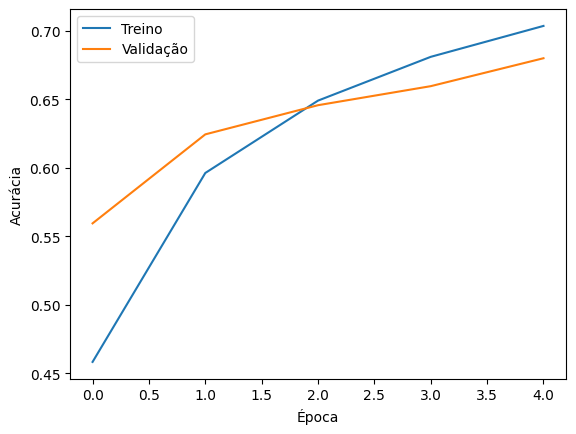

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6768 - loss: 0.9448

Acurácia no teste: 67.68%


In [ ]:
# Curvas de aprendizado
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Avaliação final
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"\nAcurácia no teste: {test_accuracy:.2%}")

### **6.1 Matriz de confusão - 5 epocas**

A **acurácia** mostra o desempenho geral do modelo.  
A **matriz de confusão** permite analisar os acertos e erros de cada classe.

- **Diagonal principal:** classificações corretas.
- **Fora da diagonal:** classes que o modelo confundiu.

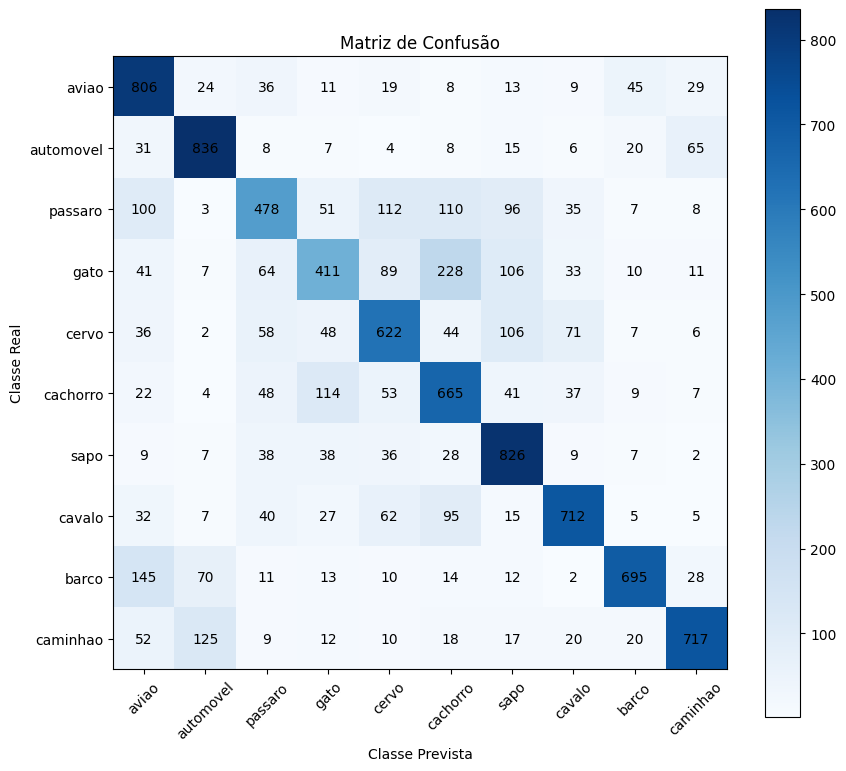

In [ ]:
# Previsões para todo o conjunto de teste
y_pred = model.predict(x_test, verbose=0)

# Classe com maior probabilidade
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusão
matriz_confusao = tf.math.confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

# Exibição
plt.figure(figsize=(9, 8))

plt.imshow(matriz_confusao, cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.colorbar()

# Valores dentro da matriz
for i in range(10):
    for j in range(10):
        plt.text(
            j, i,
            matriz_confusao[i, j].numpy(),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:

def exibir_imagem(indice):
  imagem = x_test[indice]
  classe_real = y_test[indice][0]

  # Preparar para o modelo
  imagem_modelo = np.expand_dims(imagem, axis=0)

  # Fazer a previsão
  previsoes = model.predict(imagem_modelo, verbose=0)

  classe_prevista = np.argmax(previsoes)
  confianca = np.max(previsoes)

  # Mostrar resultado
  plt.imshow(imagem)
  plt.title(
      f"Real: {class_names[classe_real]}\n"
      f"Previsto: {class_names[classe_prevista]} ({confianca:.1%})"
  )
  plt.axis("off")
  plt.show()

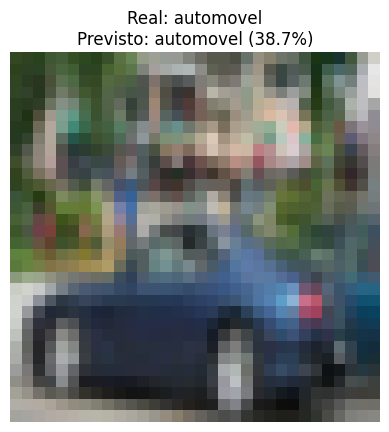

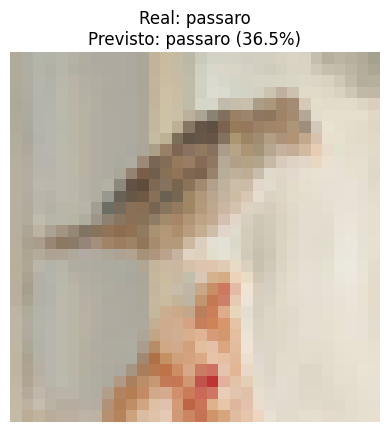

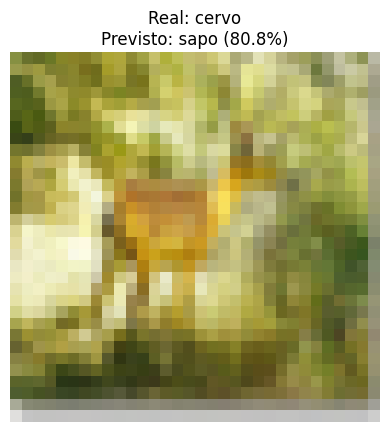

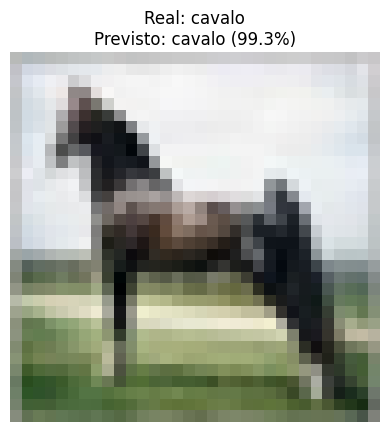

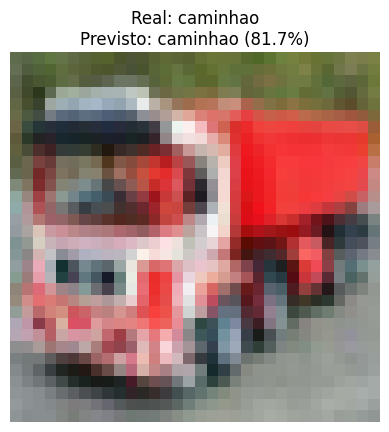

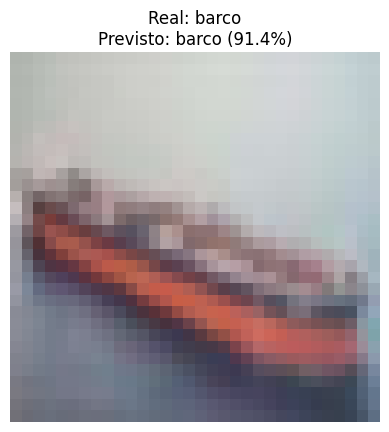

In [ ]:
exibir_imagem(122)
exibir_imagem(156)
exibir_imagem(500)
exibir_imagem(371)
exibir_imagem(666)
exibir_imagem(999)

### **8. Inferência com grupos de imagens externas (drive)**
#### Algoritimo monta o drive e é passado um "caminho".
#### Sistema busca todas as imagens contida na pasta, e
#### apresenta a original e a imagem tratada com a inferência.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


def executarInferencia():
    caminho = '/content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar'

    # Extensões aceitas
    extensoes_validas = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    # Estruturas para acumular estatísticas e registros para o futuro banco de dados
    contagem_extensoes = Counter()
    contagem_classes = Counter()
    resultados_detalhados = []

    # Obter lista de todos os arquivos da pasta
    todos_arquivos = os.listdir(caminho)

    for nome_arquivo in todos_arquivos:
        # Extrair a extensão do arquivo e contabilizar
        _, ext = os.path.splitext(nome_arquivo)
        ext_lower = ext.lower() if ext else 'sem_extensao'
        contagem_extensoes[ext_lower] += 1

        # Verificar se é uma imagem válida
        if nome_arquivo.lower().endswith(extensoes_validas):
            caminho_completo = os.path.join(caminho, nome_arquivo)

            # 1. Carregar a imagem em alta qualidade (tamanho original)
            img_original = tf.keras.utils.load_img(caminho_completo)

            # 2. Carregar a imagem tratada para a rede (32x32)
            img_tratada = tf.keras.utils.load_img(
                caminho_completo,
                target_size=(32, 32)
            )

            # Preparar a imagem para o modelo
            img_array = tf.keras.utils.img_to_array(img_tratada) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Fazer a previsão
            previsoes = model.predict(img_array, verbose=0)
            classe_idx = np.argmax(previsoes)
            confianca = float(np.max(previsoes))
            nome_classe = class_names[classe_idx]

            # Contabilizar a classe encontrada
            contagem_classes[nome_classe] += 1

            # Armazenar estrutura tratada (pronta para persistência em banco de dados)
            registro = {
                "arquivo": nome_arquivo,
                "caminho_completo": caminho_completo,
                "extensao": ext_lower,
                "objeto_detectado": nome_classe,
                "probabilidade": confianca
            }
            resultados_detalhados.append(registro)

            # 3. Exibir as duas imagens lado a lado
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))

            # Imagem Original
            axes[0].imshow(img_original)
            axes[0].set_title("Original (Alta Qualidade)")
            axes[0].axis("off")

            # Imagem Tratada
            axes[1].imshow(img_tratada)
            axes[1].set_title(
                f"Entrada do Modelo (32x32)\n"
                f"Previsto: {nome_classe} ({confianca:.1%})"
            )
            axes[1].axis("off")

            plt.suptitle(f"Arquivo: {nome_arquivo}", fontsize=12)
            plt.tight_layout()
            plt.show()
            print("=" * 100)

    # =========================================================================
    # RELATÓRIO FINAL / PERSPECTIVA DE BANCO DE DADOS
    # =========================================================================
    print("\n" + "=" * 40 + " RELATÓRIO DO DIRETÓRIO " + "=" * 40)
    print(f"Diretório Analisado: {caminho}\n")

    print("--- 1. Quantidade de Arquivos por Extensão ---")
    for ext, quant in contagem_extensoes.items():
        status = " (Válida)" if ext in extensoes_validas else " (Ignorada/Outra)"
        print(f"  • {ext}: {quant} arquivo(s){status}")

    print("\n--- 2. Resumo de Objetos Encontrados ---")
    if contagem_classes:
        for classe, quant in contagem_classes.items():
            print(f"  • {classe}: {quant} imagem(ns)")
    else:
        print("  Nenhuma imagem válida foi processada.")

    print("\n--- 3. Detalhamento de Imagens e Probabilidades ---")
    for item in resultados_detalhados:
        print(
            f"  [Arquivo: {item['arquivo']}] -> "
            f"Objeto: {item['objeto_detectado']} | "
            f"Probabilidade: {item['probabilidade']:.2%} ({item['probabilidade']:.4f})"
        )

    print("=" * 104)

    # Retornamos os resultados estruturados caso deseje salvar em tabela/BD externamente
    return resultados_detalhados

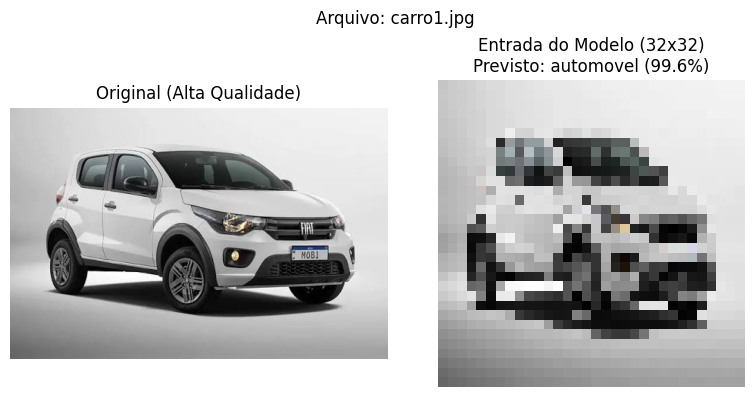

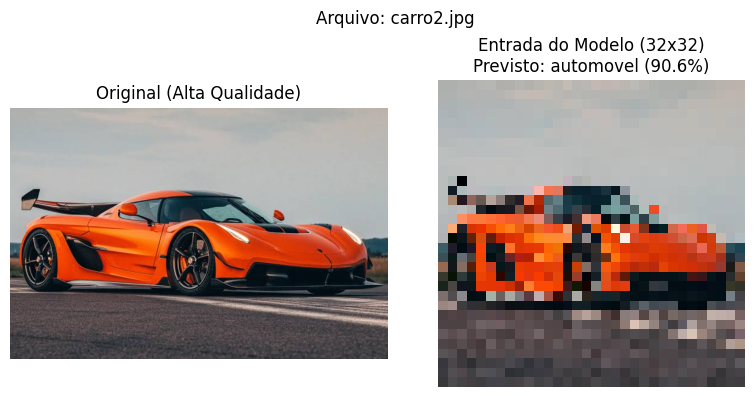

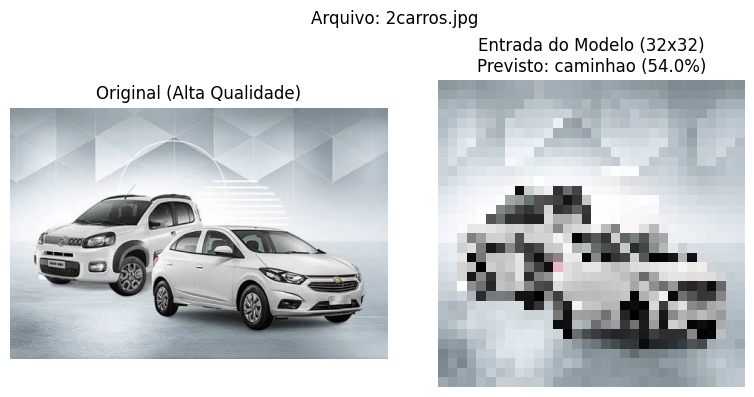

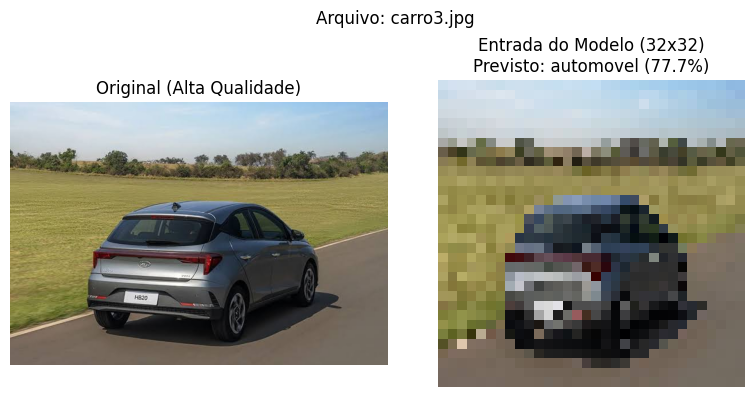

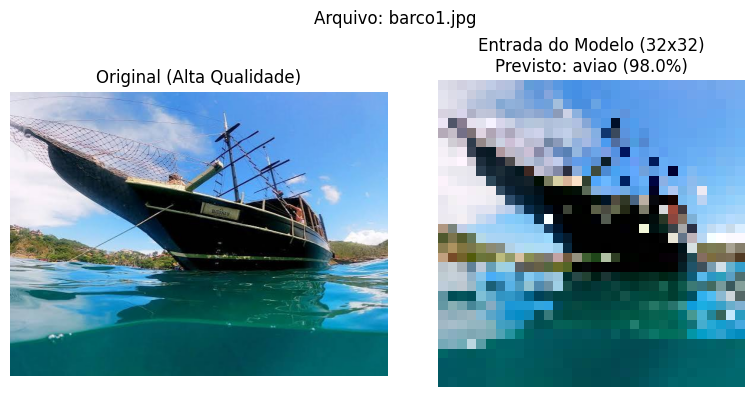

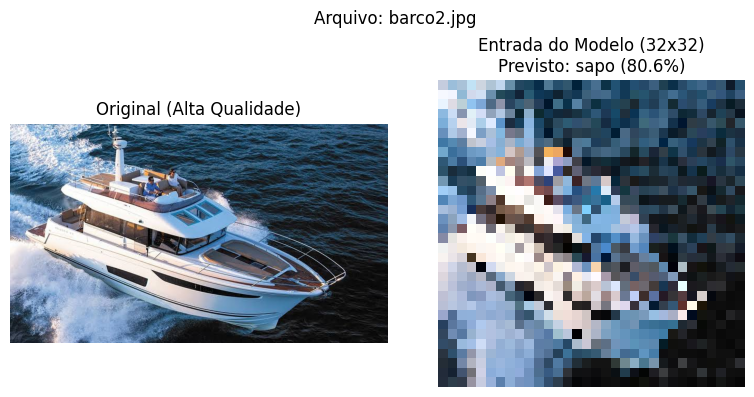

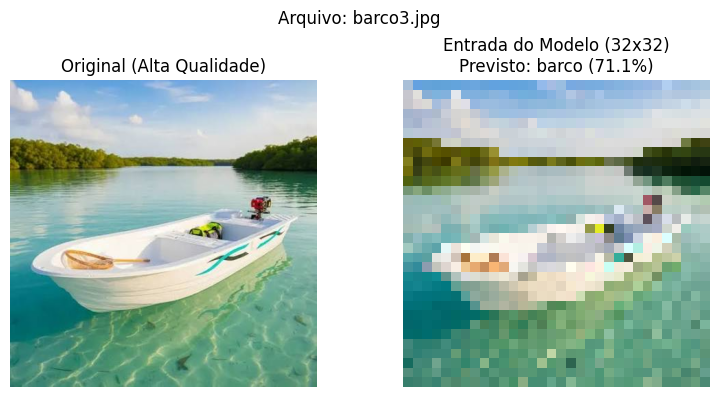

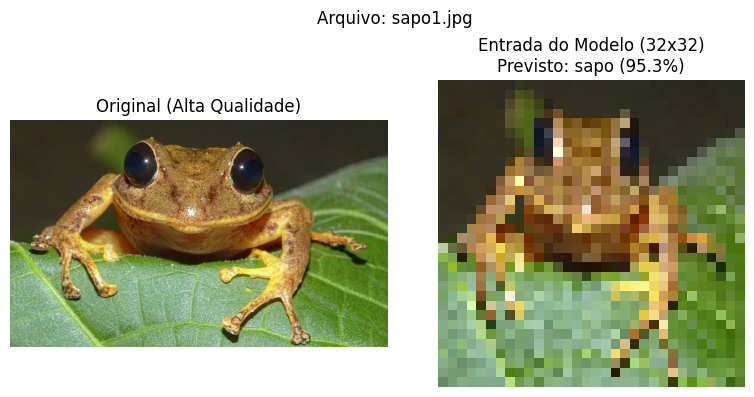

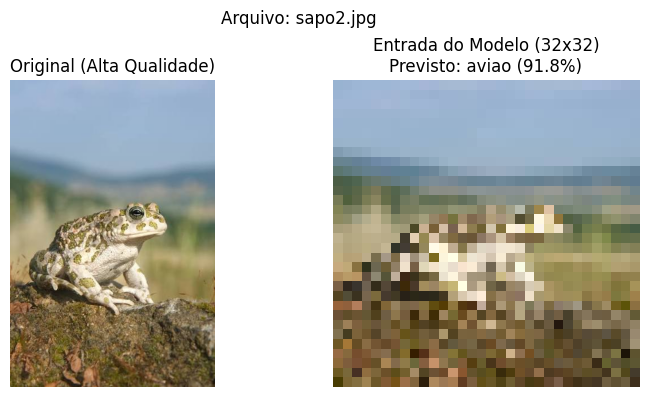

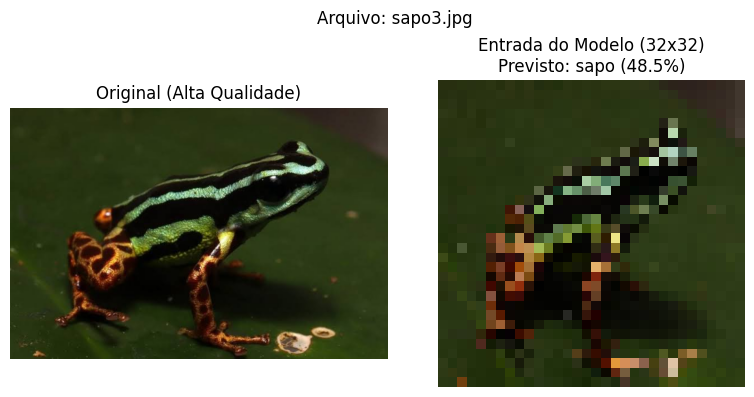

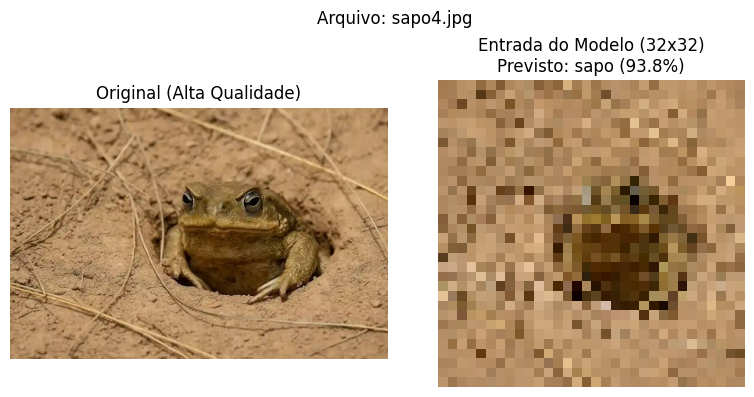

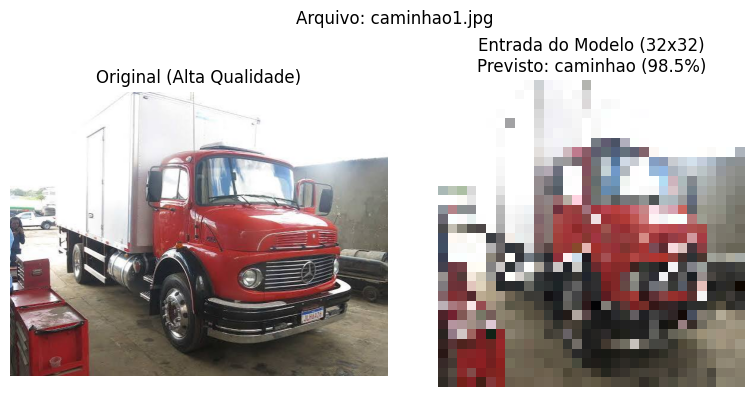

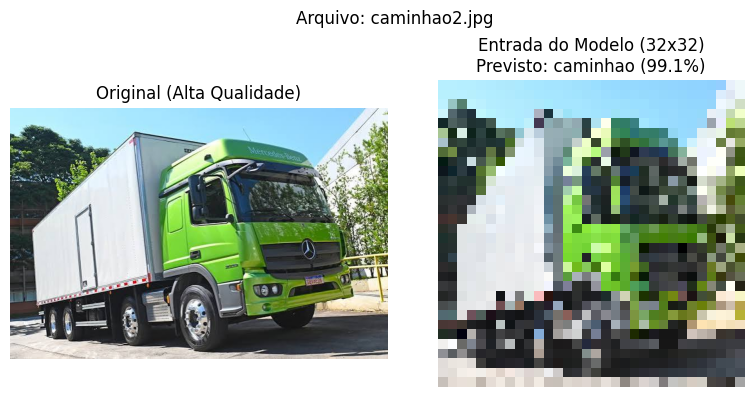

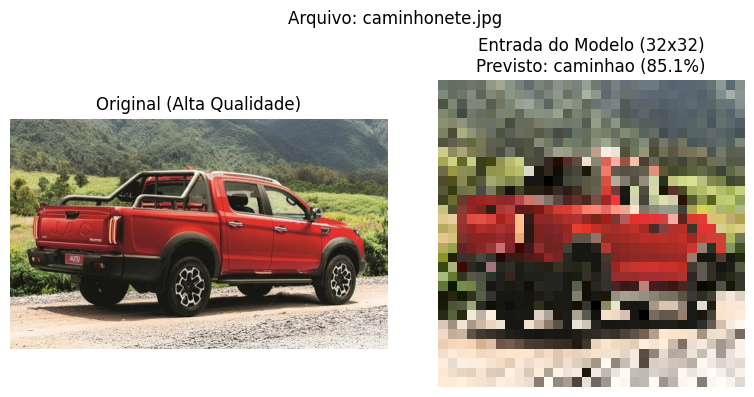


======================================== RELATÓRIO DO DIRETÓRIO ========================================
Diretório Analisado: /content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar

--- 1. Quantidade de Arquivos por Extensão ---
  • .jpg: 14 arquivo(s) (Válida)

--- 2. Resumo de Objetos Encontrados ---
  • automovel: 3 imagem(ns)
  • caminhao: 4 imagem(ns)
  • aviao: 2 imagem(ns)
  • sapo: 4 imagem(ns)
  • barco: 1 imagem(ns)

--- 3. Detalhamento de Imagens e Probabilidades ---
  [Arquivo: carro1.jpg] -> Objeto: automovel | Probabilidade: 99.58% (0.9958)
  [Arquivo: carro2.jpg] -> Objeto: automovel | Probabilidade: 90.55% (0.9055)
  [Arquivo: 2carros.jpg] -> Objeto: caminhao | Probabilidade: 53.98% (0.5398)
  [Arquivo: carro3.jpg] -> Objeto: automovel | Probabilidade: 77.69% (0.7769)
  [Arquivo: barco1.jpg] -> Objeto: aviao | Probabilidade: 98.01% (0.9801)
  [Arquivo: barco2.jpg] -> Objeto: sapo | Probabilidade: 80.62% (0.8062)
  [Arquivo: bar

[{'arquivo': 'carro1.jpg',
  'caminho_completo': '/content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar/carro1.jpg',
  'extensao': '.jpg',
  'objeto_detectado': 'automovel',
  'probabilidade': 0.9958158135414124},
 {'arquivo': 'carro2.jpg',
  'caminho_completo': '/content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar/carro2.jpg',
  'extensao': '.jpg',
  'objeto_detectado': 'automovel',
  'probabilidade': 0.9055204391479492},
 {'arquivo': '2carros.jpg',
  'caminho_completo': '/content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar/2carros.jpg',
  'extensao': '.jpg',
  'objeto_detectado': 'caminhao',
  'probabilidade': 0.5398082733154297},
 {'arquivo': 'carro3.jpg',
  'caminho_completo': '/content/drive/MyDrive/MATERIAS - EC/LIA1 - Laboratório de Inovação e Automação/Imagens_Analisar/carro3.jpg',
  'extensao': '.jpg',
  'objeto_detectado': 'automovel',
  'probabil

In [ ]:
executarInferencia()

### **9. Nova rotina de treinamento**


Treinamento será executado até que ocorra estagnacao, com paciencia de 5 Epocas

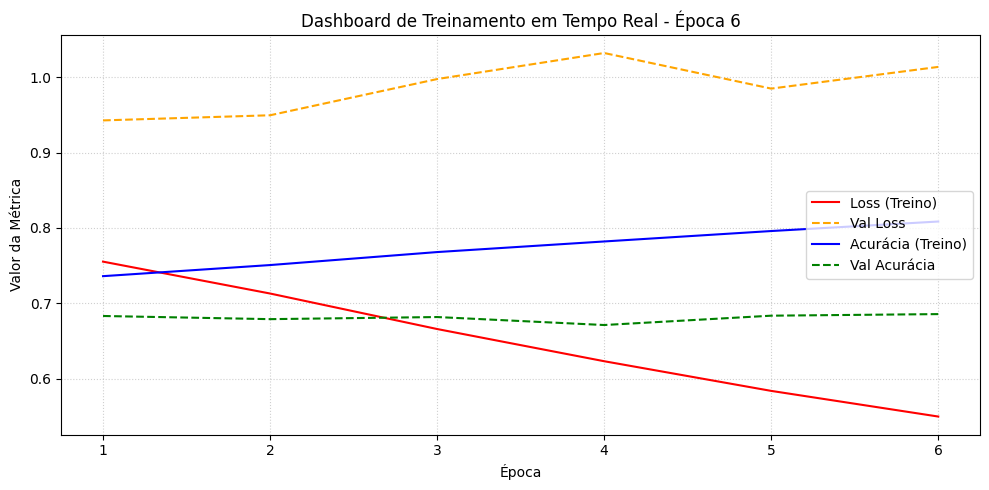

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.8085 - loss: 0.5496 - val_accuracy: 0.6856 - val_loss: 1.0138
Epoch 6: early stopping


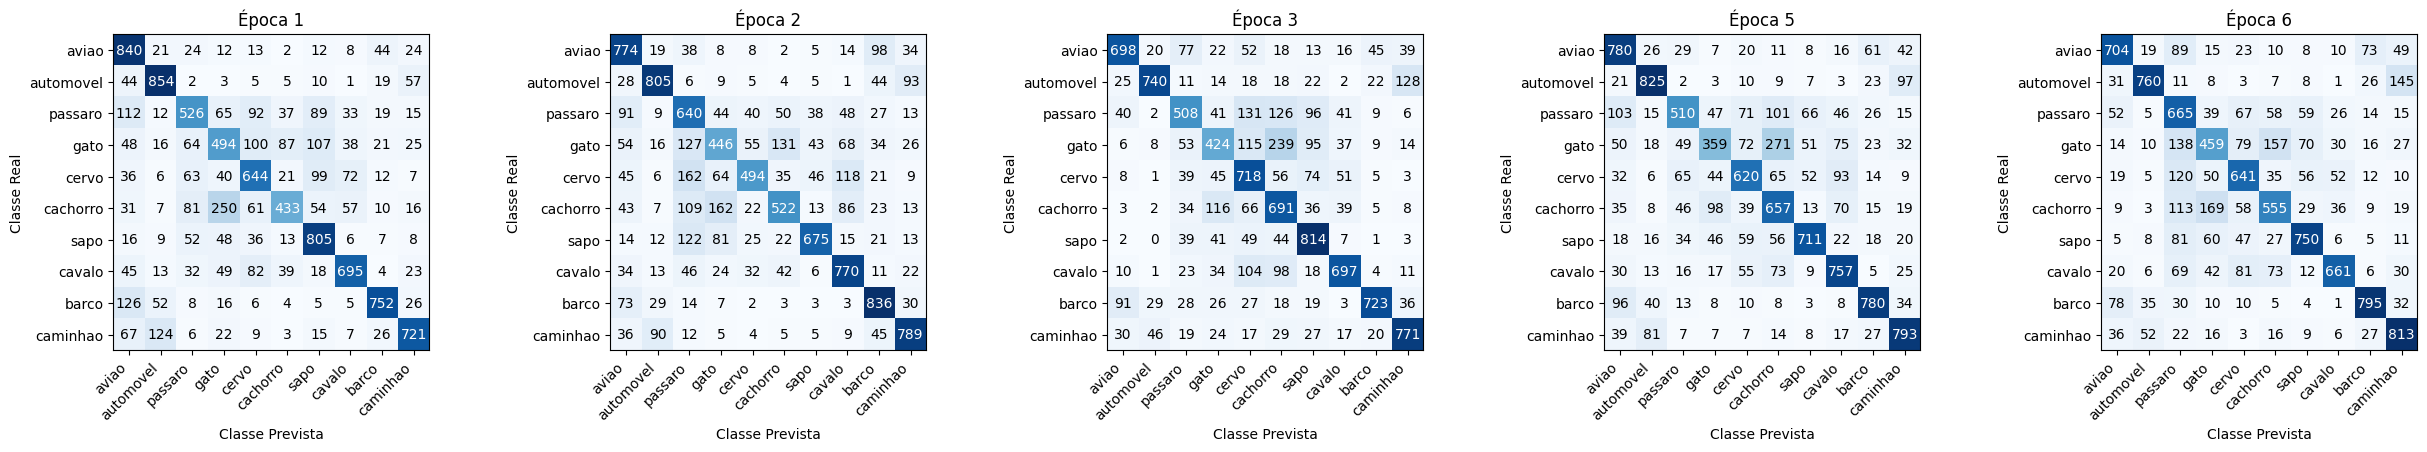

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import clear_output

class DynamicDashboardCallback(tf.keras.callbacks.Callback):
    """
    Callback customizado para:
    1. Atualizar o gráfico dinâmico (dashboard) a cada época.
    2. Armazenar a matriz de confusão de cada época.
    """
    def __init__(self, x_test, y_test, num_classes=10):
        super().__init__()
        self.x_test = x_test
        self.y_test = y_test.flatten()
        self.num_classes = num_classes

        self.history_metrics = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }
        self.confusion_matrices = []

    def on_epoch_end(self, epoch, logs=None):
        # 1. Registrar métricas da época atual
        for key in self.history_metrics.keys():
            self.history_metrics[key].append(logs.get(key))

        # 2. Gerar e armazenar matriz de confusão para a época atual
        y_pred = self.model.predict(self.x_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        cm = tf.math.confusion_matrix(
            self.y_test,
            y_pred_classes,
            num_classes=self.num_classes
        ).numpy()
        self.confusion_matrices.append(cm)

        # 3. Desenhar/Atualizar o Dashboard ao vivo no Jupyter/Colab
        clear_output(wait=True)
        epochs_range = range(1, len(self.history_metrics['loss']) + 1)

        plt.figure(figsize=(10, 5))
        plt.plot(epochs_range, self.history_metrics['loss'], label='Loss (Treino)', color='red')
        plt.plot(epochs_range, self.history_metrics['val_loss'], label='Val Loss', color='orange', linestyle='--')
        plt.plot(epochs_range, self.history_metrics['accuracy'], label='Acurácia (Treino)', color='blue')
        plt.plot(epochs_range, self.history_metrics['val_accuracy'], label='Val Acurácia', color='green', linestyle='--')

        plt.title(f'Dashboard de Treinamento em Tempo Real - Época {epoch + 1}')
        plt.xlabel('Época')
        plt.ylabel('Valor da Métrica')
        plt.legend(loc='center right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

# --- 1. Configuração dos Callbacks ---

# Callback dinâmico (Dashboard + Histórico de Matrizes)
dashboard_cb = DynamicDashboardCallback(x_test, y_test, num_classes=len(class_names))

# Interrupção precoce: para se a perda de validação estagnar/subir por 5 épocas seguidas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.0001,
    mode='min',
    verbose=1
)

# --- 2. Treinamento com limite de 500 épocas ---

history = model.fit(
    x_train,
    y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[dashboard_cb, early_stopping_cb]
)

# --- 3. Exibição das 5 Matrizes de Confusão Equidistantes ---

def plot_5_equidistant_matrices(matrices, class_names):
    total_epochs = len(matrices)

    # Seleção dos 5 índices percentuais: 0% (Época 1), 25%, 50%, 75% e 100% (Última)
    percentiles = [0.0, 0.25, 0.50, 0.75, 1.0]
    indices = [int(np.round((total_epochs - 1) * p)) for p in percentiles]

    # Eliminar duplicatas caso o treinamento termine em menos de 5 épocas
    indices = sorted(list(dict.fromkeys(indices)))

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4.5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        cm = matrices[idx]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"Época {idx + 1}")
        ax.set_xlabel("Classe Prevista")
        ax.set_ylabel("Classe Real")

        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)

        # Inserção dos números dentro das células da matriz
        max_val = cm.max() if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > max_val / 2 else "black"
                )

    plt.tight_layout()
    plt.show()

# Executar a plotagem das 5 matrizes
plot_5_equidistant_matrices(dashboard_cb.confusion_matrices, class_names)

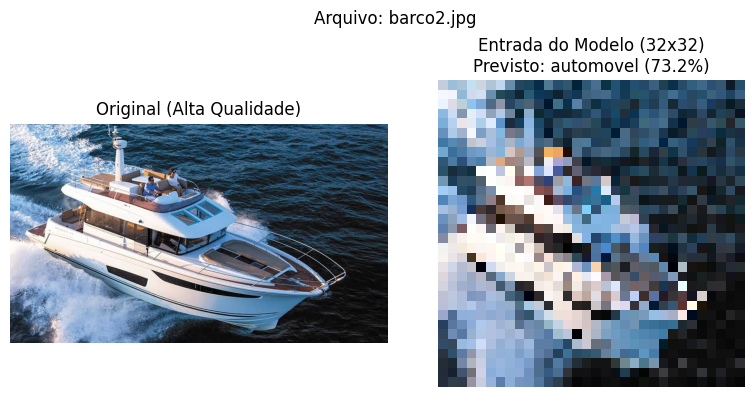

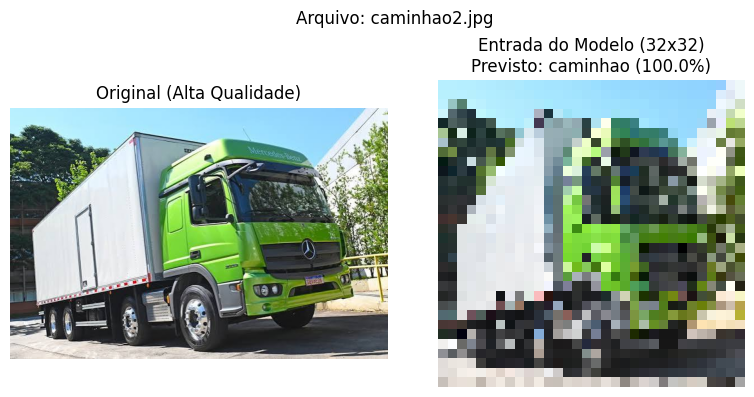

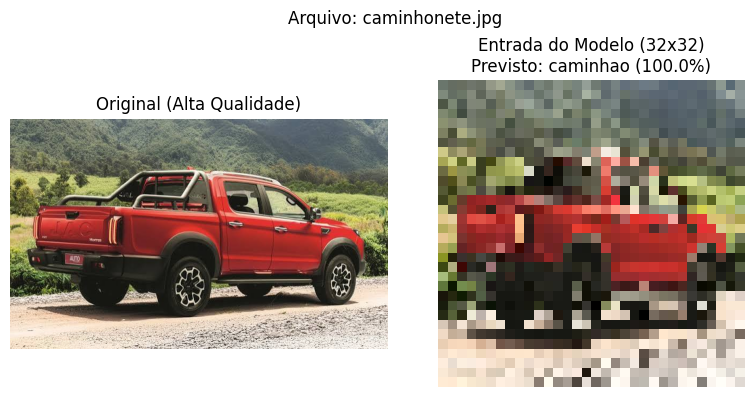

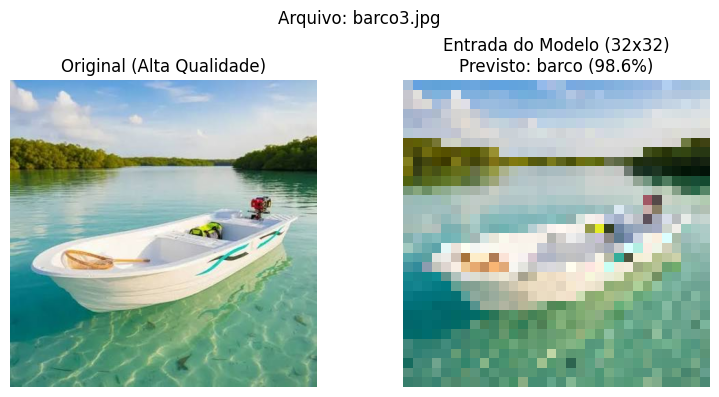

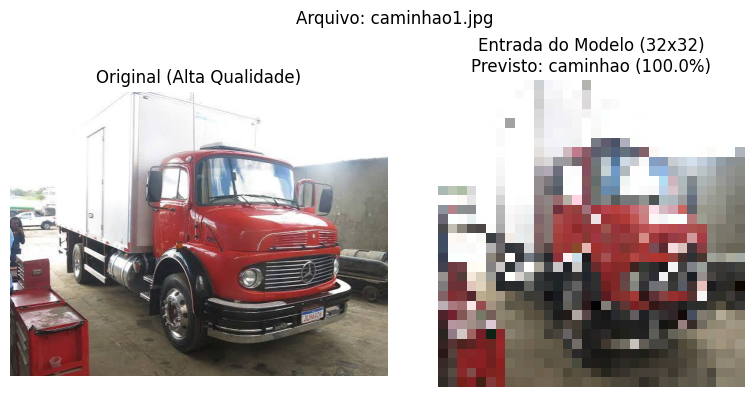

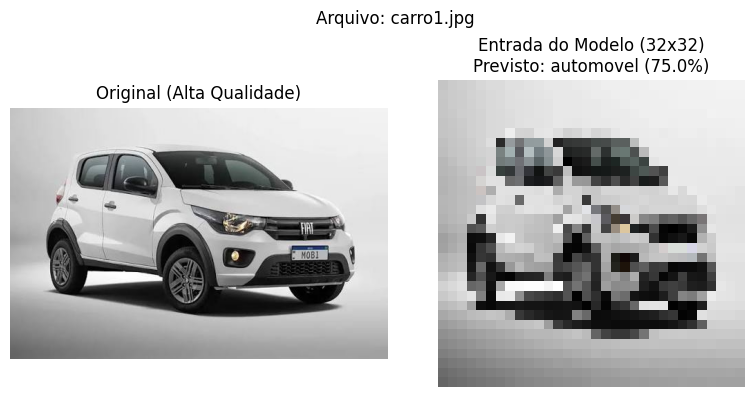

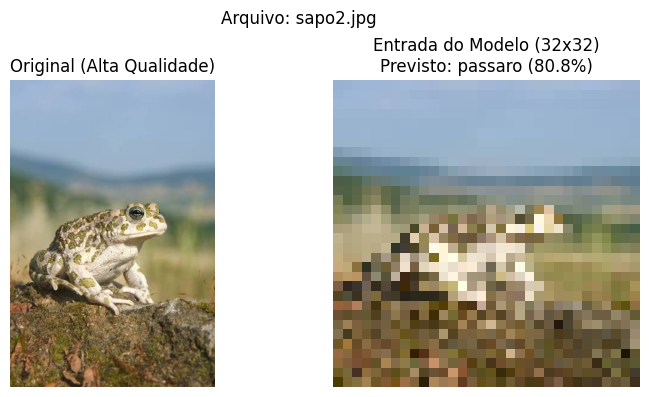

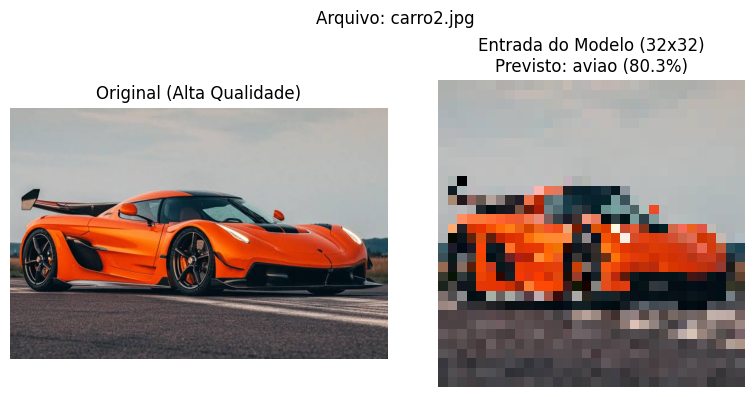

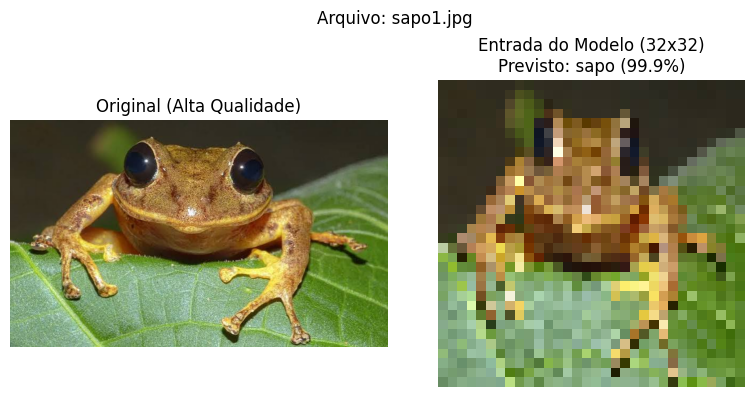

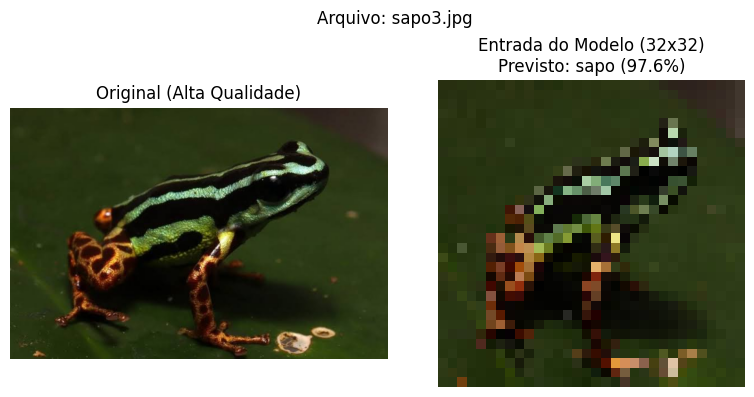

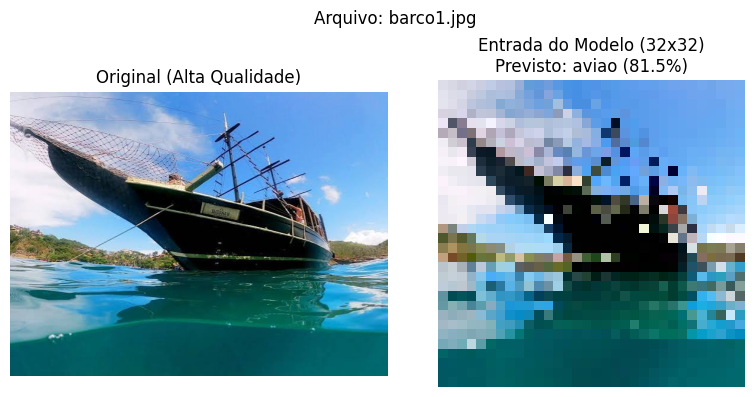

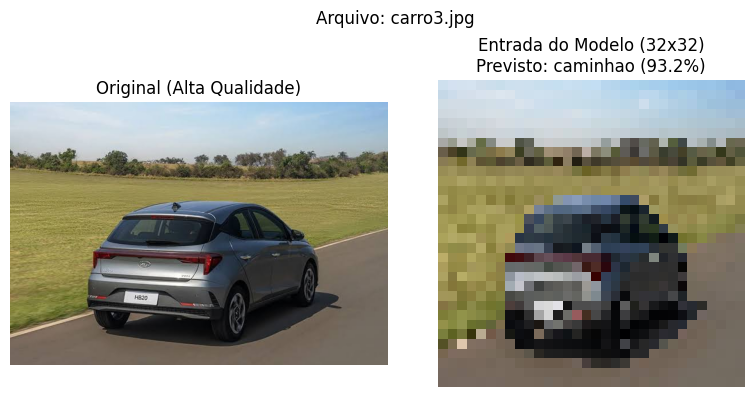

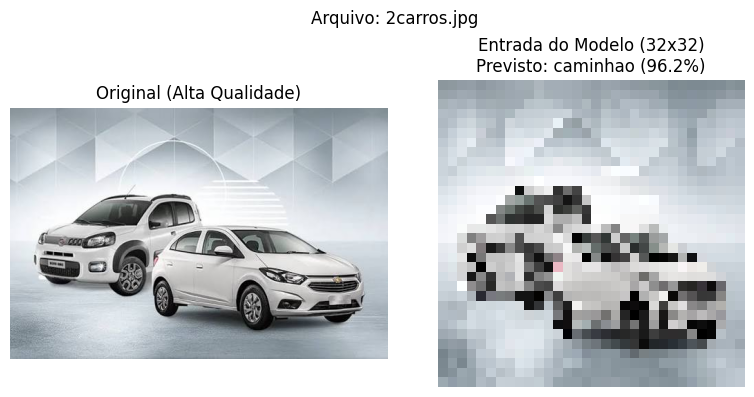

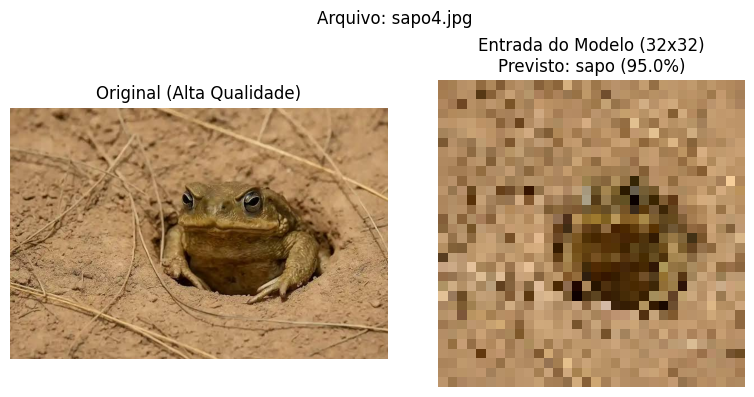

In [ ]:
executarInferencia()

### **10 - Treinamento Final - 50 Epocas no mínimo... paciencia de 5 epocas**



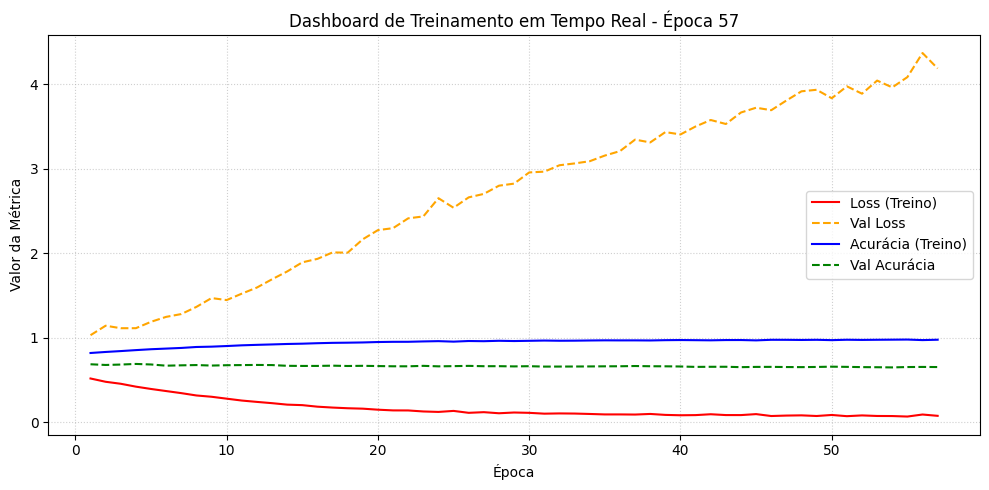

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.9753 - loss: 0.0740 - val_accuracy: 0.6517 - val_loss: 4.1881
Epoch 57: early stopping
Restoring model weights from the end of the best epoch: 52.


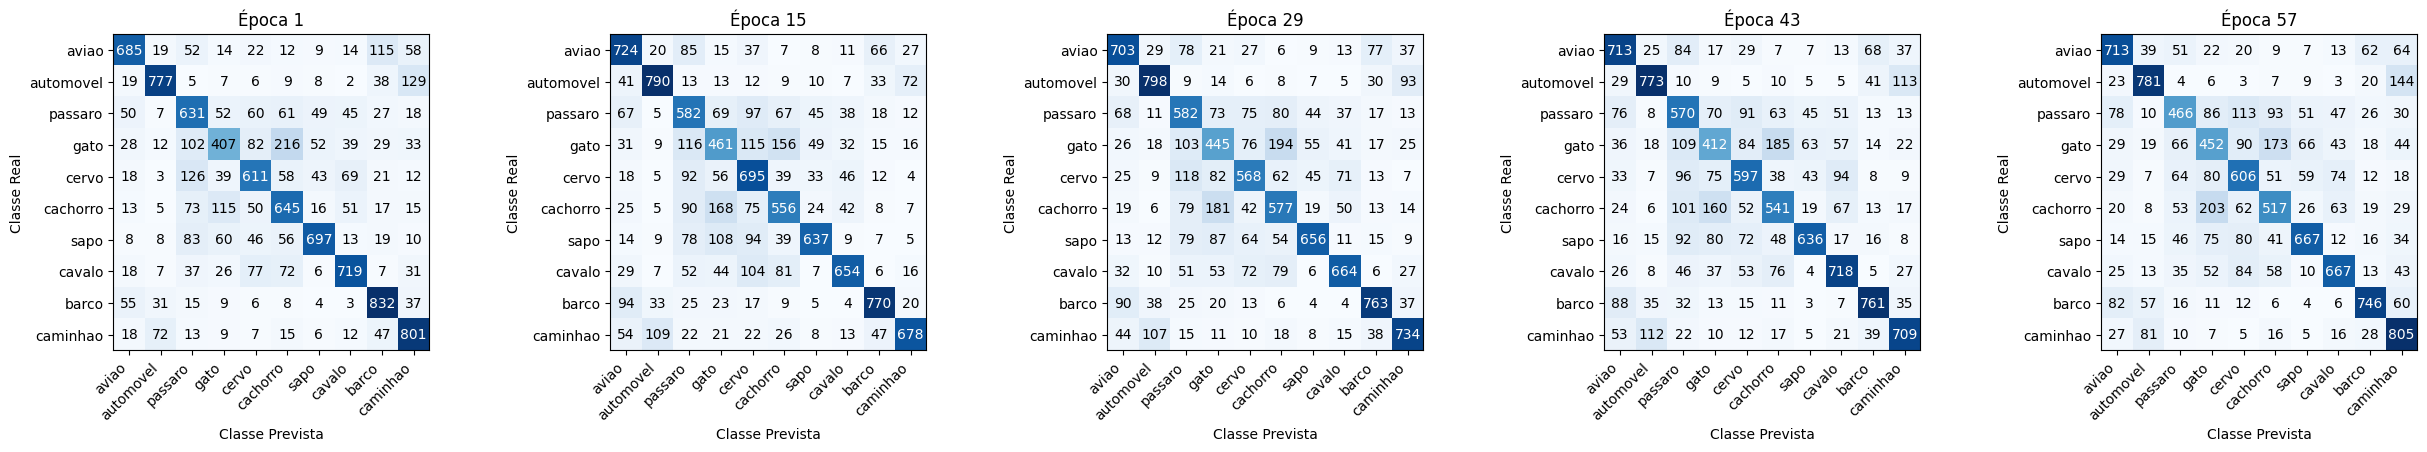

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import clear_output

class DynamicDashboardCallback(tf.keras.callbacks.Callback):
    """
    Callback customizado para:
    1. Atualizar o gráfico dinâmico (dashboard) a cada época.
    2. Armazenar a matriz de confusão de cada época.
    3. Salvar automaticamente a imagem do gráfico no disco.
    """
    def __init__(self, x_test, y_test, num_classes=10, save_dir="graficos_treino", img_format="jpg"):
        super().__init__()
        self.x_test = x_test
        self.y_test = y_test.flatten()
        self.num_classes = num_classes
        self.save_dir = save_dir
        self.img_format = img_format

        # Cria o diretório para salvar as imagens caso não exista
        if self.save_dir:
            os.makedirs(self.save_dir, exist_ok=True)

        self.history_metrics = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }
        self.confusion_matrices = []

    def on_epoch_end(self, epoch, logs=None):
        # 1. Registrar métricas da época atual
        for key in self.history_metrics.keys():
            self.history_metrics[key].append(logs.get(key))

        # 2. Gerar e armazenar matriz de confusão para a época atual
        y_pred = self.model.predict(self.x_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        cm = tf.math.confusion_matrix(
            self.y_test,
            y_pred_classes,
            num_classes=self.num_classes
        ).numpy()
        self.confusion_matrices.append(cm)

        # 3. Desenhar/Atualizar o Dashboard ao vivo no Jupyter/Colab
        clear_output(wait=True)
        epochs_range = range(1, len(self.history_metrics['loss']) + 1)

        plt.figure(figsize=(10, 5))
        plt.plot(epochs_range, self.history_metrics['loss'], label='Loss (Treino)', color='red')
        plt.plot(epochs_range, self.history_metrics['val_loss'], label='Val Loss', color='orange', linestyle='--')
        plt.plot(epochs_range, self.history_metrics['accuracy'], label='Acurácia (Treino)', color='blue')
        plt.plot(epochs_range, self.history_metrics['val_accuracy'], label='Val Acurácia', color='green', linestyle='--')

        plt.title(f'Dashboard de Treinamento em Tempo Real - Época {epoch + 1}')
        plt.xlabel('Época')
        plt.ylabel('Valor da Métrica')
        plt.legend(loc='center right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()

        # Salvar o gráfico em formato de imagem a cada época
        if self.save_dir:
            filename = os.path.join(self.save_dir, f"dashboard_epoch_{epoch + 1:03d}.{self.img_format}")
            plt.savefig(filename, dpi=150, bbox_inches='tight')

        plt.show()

# --- 1. Configuração dos Callbacks ---

# Callback dinâmico com salvamento de imagens
dashboard_cb = DynamicDashboardCallback(
    x_test,
    y_test,
    num_classes=len(class_names),
    save_dir="graficos_treino",
    img_format="jpg"
)

# Early Stopping configurado para garantir no mínimo 50 épocas:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # Monitora a perda na validação (perda de rendimento)
    patience=5,                # Se ficar 5 épocas seguidas sem melhorar, ele para
    min_delta=0.0001,          # Melhoria mínima exigida
    mode='min',
    verbose=1,
    start_from_epoch=50,       # <-- GARANTE NO MÍNIMO 50 ÉPOCAS ANTES DE ANALISAR A PARADA
    restore_best_weights=True  # Restaura os pesos da melhor época se houver parada prematura
)

# --- 2. Treinamento ---

history = model.fit(
    x_train,
    y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[dashboard_cb, early_stopping_cb]
)

# --- 3. Exibição das 5 Matrizes de Confusão Equidistantes ---

def plot_5_equidistant_matrices(matrices, class_names):
    total_epochs = len(matrices)

    # Seleção dos 5 índices percentuais (do início até o final real do treino)
    percentiles = [0.0, 0.25, 0.50, 0.75, 1.0]
    indices = [int(np.round((total_epochs - 1) * p)) for p in percentiles]
    indices = sorted(list(dict.fromkeys(indices)))

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4.5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        cm = matrices[idx]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"Época {idx + 1}")
        ax.set_xlabel("Classe Prevista")
        ax.set_ylabel("Classe Real")

        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)

        max_val = cm.max() if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > max_val / 2 else "black"
                )

    plt.tight_layout()
    plt.show()

plot_5_equidistant_matrices(dashboard_cb.confusion_matrices, class_names)